

# RA1 - Trabajo Práctico N°2 - Grupo 4: Introduccion al Análisis Exploratorio de Datos (EDA)



## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Reproducibilidad
np.random.seed(42)

# Estética general de los gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Opciones de visualización de pandas
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 20)

print("Entorno configurado.")

Entorno configurado.


## Ejercicio N°1 - Comprensión inicial de datos reales



### 1.   Comprensión estructural del dataset




Esta consigna presenta un escenario en el que se pretende predecir el precio de propiedades inmuebles, y determinar características ligadas a la variación del mismo. Para ello, se dispone de un *dataset* (contenido en propiedades.csv), en el cual cada fila representa una propiedad, y cada columna, una característica de las listadas a continuación:


*   `id`: Identificador único para cada propiedad.
*   `precio`: Valor monetario del inmueble (*target* del modelo).
*   `superficie_m2`, `habitaciones`, `antiguedad_años` y `precio_m2`: Características numéricas del inmueble.
*   `barrio`: Variable categórica que refiere a la ubicación de la propiedad.

Por consiguiente, se realiza la carga del *dataset* para profundizar en su análisis estructural.








In [2]:
!unzip datasets_TP2.zip

Archive:  datasets_TP2.zip
  inflating: dataset_desconocido.csv  
  inflating: propiedades.csv         
  inflating: clientes_churn.csv      


In [3]:
dataset = pd.read_csv("/content/propiedades.csv")

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Como puede apreciarse en la información del dataset, el mismo cuenta con 800 elementos, lo cual se asume una cantidad óptima para extraer conclusiones. También queda claro que, para todas las variables, el tipo de datos utilizado es correcto. No obstante, hay tres variables que presentan valores nulos, por lo que será necesario limpiar el dataset.

### 2. Calidad de los datos



Para comenzar, se evalúan los datos faltantes en cada categoría:



In [ ]:
missing_data = dataset.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    missing_percentage = (missing_data / len(dataset)) * 100
    missing_info = pd.DataFrame({
        'Cantidad de Nulos': missing_data,
        'Porcentaje de Nulos': missing_percentage
    }).sort_values(by='Porcentaje de Nulos', ascending=False)

    # Convert 'Cantidad de Nulos' to integer type
    missing_info['Cantidad de Nulos'] = missing_info['Cantidad de Nulos'].astype(int)
    # Format 'Porcentaje de Nulos' with two decimal places and a percentage symbol
    missing_info['Porcentaje de Nulos'] = missing_info['Porcentaje de Nulos'].apply(lambda x: f'{x:,.2f}%')

    print("Variables con valores nulos y su porcentaje:")
    print(missing_info)
else:
    print("No hay variables con valores nulos en el dataset.")

Variables con valores nulos y su porcentaje:
                 Cantidad de Nulos Porcentaje de Nulos
antiguedad_años                 48               6.00%
precio                          32               4.00%
precio_m2                       32               4.00%


Para el caso de los faltantes en `precio`, dado que dicha característica es el target no se puede imputar los datos, atendiendo al riesgo de un posible sesgo, entonces se opta por eliminar los faltantes, lo cual es permisible debido al bajo porcentaje que representan respecto al total. Puesto que `precio_m2` es la característica resultante de la división entre `precio` y `superficie`, los faltantes de este *feature* son los mismos que para `precio`.

In [6]:
# Eliminar filas con valores nulos en la columna 'precio'
dataset.dropna(subset=['precio'], inplace=True)

# Imprimir los nulos restantes para cada feature
print("Valores nulos restantes por columna después de eliminar nulos en 'precio':")
print(dataset.isnull().sum())

Valores nulos restantes por columna después de eliminar nulos en 'precio':
id                  0
precio              0
superficie_m2       0
habitaciones        0
antiguedad_años    43
barrio              0
precio_m2           0
dtype: int64


Por otro lado, los nulos en `antigüedad_años` pueden imputarse para no perder tantas muestras, valiéndose del método KNN para una mayor precisión.

In [7]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas numéricas relevantes para la imputación
# Se incluyen 'superficie_m2', 'habitaciones', y 'precio_m2' ya que pueden estar correlacionadas
# con la antigüedad y ayudar a una imputación más precisa.
columns_for_imputation = ['superficie_m2', 'habitaciones', 'antiguedad_años', 'precio_m2']
dataset_numeric = dataset[columns_for_imputation].copy()

# Inicializar y aplicar el escalador
scaler = StandardScaler()
dataset_scaled = scaler.fit_transform(dataset_numeric)

# Convertir el array escalado de nuevo a un DataFrame para mantener los nombres de las columnas
dataset_scaled_df = pd.DataFrame(dataset_scaled, columns=columns_for_imputation, index=dataset_numeric.index)

# Inicializar el imputador KNN
# n_neighbors=5 es un valor común, se puede ajustar si es necesario.
# weights='uniform' asigna un peso igual a todos los vecinos, mientras que 'distance' asigna un peso
# basado en la inversa de la distancia de cada vecino. Usaremos uniform para empezar.
imputer = KNNImputer(n_neighbors=5, weights='uniform')

# Aplicar la imputación sobre los datos escalados
dataset_imputed_scaled_array = imputer.fit_transform(dataset_scaled_df)

# Convertir el array imputado y escalado de nuevo a un DataFrame
dataset_imputed_scaled_df = pd.DataFrame(dataset_imputed_scaled_array, columns=columns_for_imputation, index=dataset_numeric.index)

# Invertir la transformación para la columna 'antiguedad_años' antes de actualizar el DataFrame original
# Para hacer esto correctamente, necesitamos inverse_transform solo la columna relevante.
# Sin embargo, el inverse_transform de StandardScaler necesita un array 2D.
# La forma más sencilla es inverse_transformar todo el dataset_imputed_scaled_df y luego extraer la columna.
# Creamos un dummy array con ceros y la columna de interes para la transformacion inversa
dummy_array = np.zeros_like(dataset_imputed_scaled_array)
dummy_array[:, columns_for_imputation.index('antiguedad_años')] = dataset_imputed_scaled_array[:, columns_for_imputation.index('antiguedad_años')]
dataset_imputed_original_scale = scaler.inverse_transform(dataset_imputed_scaled_array)

# Actualizar la columna 'antiguedad_años' en el DataFrame original con los valores desescalados
dataset['antiguedad_años'] = dataset_imputed_original_scale[:, columns_for_imputation.index('antiguedad_años')]

# Imprimir los nulos restantes para cada feature para verificar
print("Valores nulos restantes por columna después de la imputación KNN en 'antiguedad_años':")
print(dataset.isnull().sum())

Valores nulos restantes por columna después de la imputación KNN en 'antiguedad_años':
id                 0
precio             0
superficie_m2      0
habitaciones       0
antiguedad_años    0
barrio             0
precio_m2          0
dtype: int64


### 3. Estadística descriptiva

En este apartado, se imprimen descriptores que permiten entender mejor la distribución de los datos, y qué tan representativa es la media para cada población.

In [ ]:
numerical_cols = dataset.select_dtypes(include=['number']).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id') # Explicitly remove 'id' from the list of numerical columns for descriptive stats

descriptive_stats = dataset[numerical_cols].describe().T

def calculate_cv(series):
    if series.mean() == 0:
        return np.nan # Avoid division by zero
    return series.std() / series.mean()

# Calculate Coefficient of Variation for each numerical column
descriptive_stats['CV'] = dataset[numerical_cols].apply(calculate_cv)

print("Descriptores de las variables numéricas")
print(descriptive_stats)

Descriptores de las variables numéricas
                 count       mean        std       min        25%        50%  \
precio          768.00 200,636.74 142,582.54 19,900.00 102,900.00 160,000.00   
superficie_m2   768.00     117.73     157.09     28.00      62.18      90.70   
habitaciones    768.00       3.42       1.62      1.00       2.00       3.00   
antiguedad_años 768.00      22.01      18.22      0.00       5.00      18.30   
precio_m2       768.00   1,961.88     988.50    116.18   1,322.42   1,841.94   

                       75%        max   CV  
precio          264,075.00 994,200.00 0.71  
superficie_m2       128.93   2,700.00 1.33  
habitaciones          5.00       7.00 0.47  
antiguedad_años      37.00      59.00 0.83  
precio_m2         2,436.20  10,111.36 0.50  


En vista de los altos valores de CV, se puede asumir que la media no es representativa de los valores de las variables, y que existe mucha dispersión con respecto a la misma, sobre todo en la superficie y la antigüedad.

### 4. Visualización y detección de outliers

Habiendo eliminado los datos nulos, la limpieza continúa considerando posibles outliers. Para ello, se realizan boxplots y gráficas de distribuciones para las variables numéricas en busca de valores anómalos o errores en la carga.

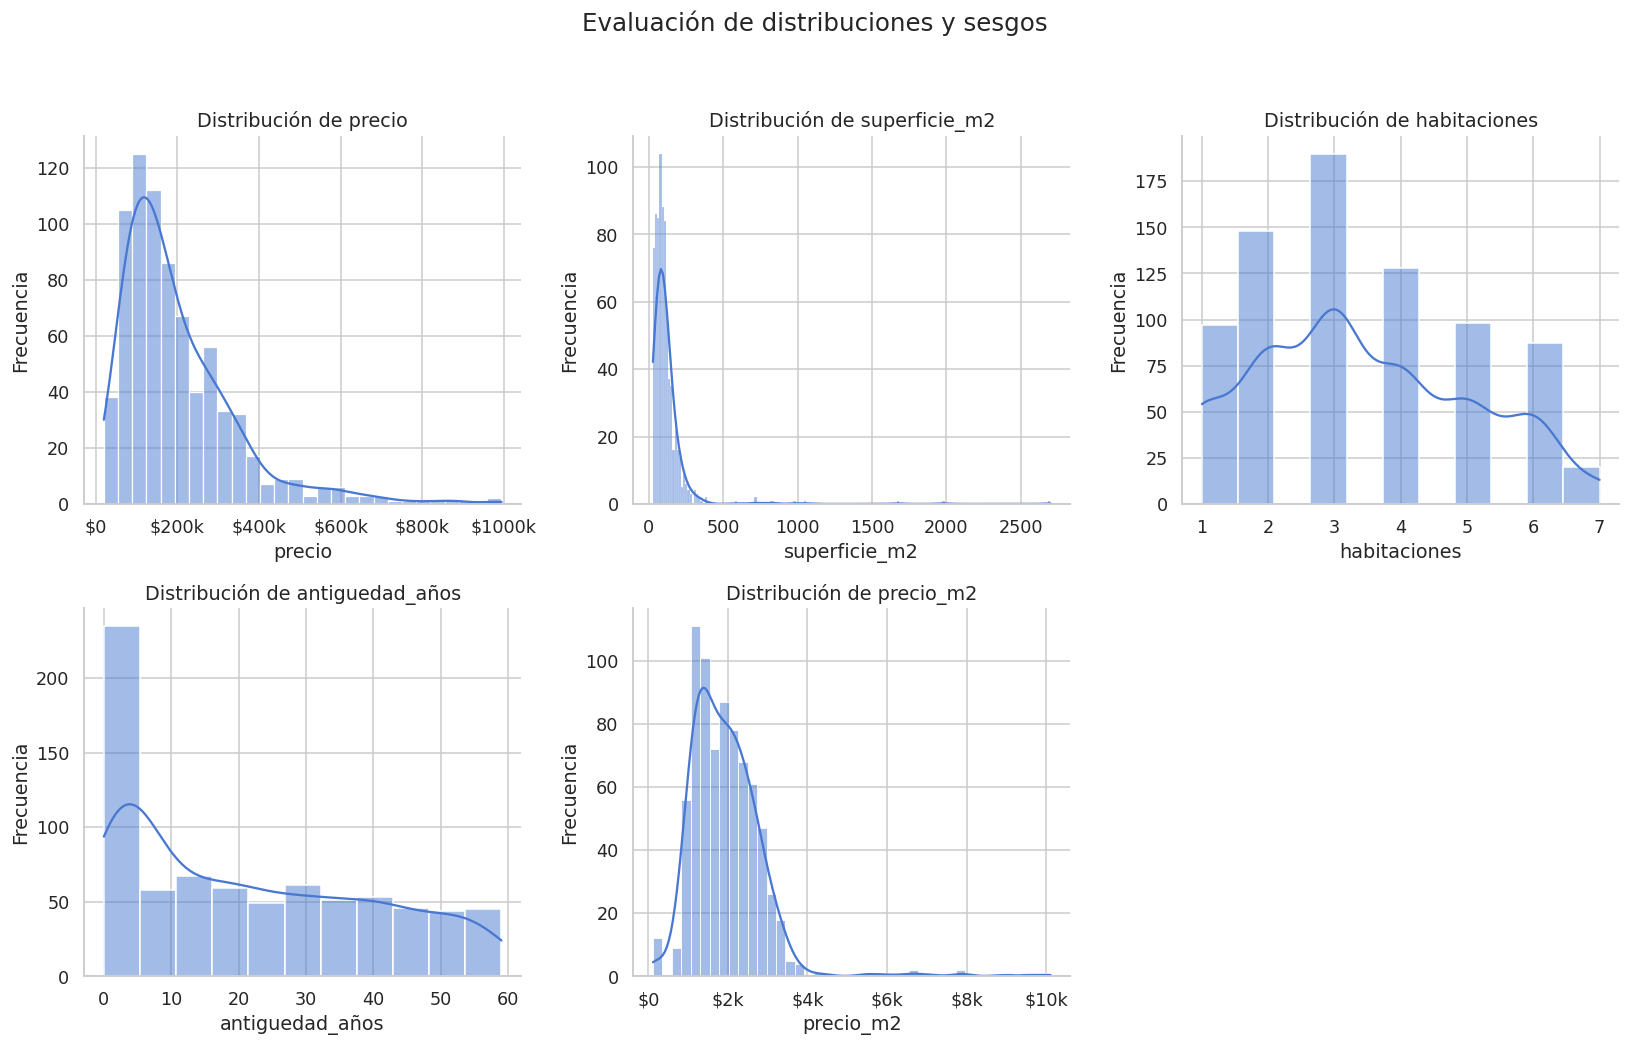

In [ ]:
from matplotlib.ticker import FuncFormatter

numerical_cols = dataset.select_dtypes(include=['number']).columns.tolist()
# Exclude 'id' as it's an identifier and not a variable for distribution analysis
if 'id' in numerical_cols:
    numerical_cols.remove('id')

def currency_formatter(x, pos):
    'The two args are the value and tick position'
    if x >= 1000:
        return '$%.0fk' % (x * 1e-3)
    else:
        return '$%.0f' % x

plt.figure(figsize=(15, 10))
plt.suptitle('Evaluación de distribuciones y sesgos', fontsize=16) # Main title for the figure
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i) # Adjust grid size as needed
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    if col == 'precio' or col == 'precio_m2':
        plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter)) # Applying formatter to x-axis
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Las distribuciones de `precio` y `superficie_m2` son aproximadamente gaussianas, pero evidencian un fuerte sesgo a la derecha, lo cual indicaría que los valores muy por encima de la media son anomalías aisladas.

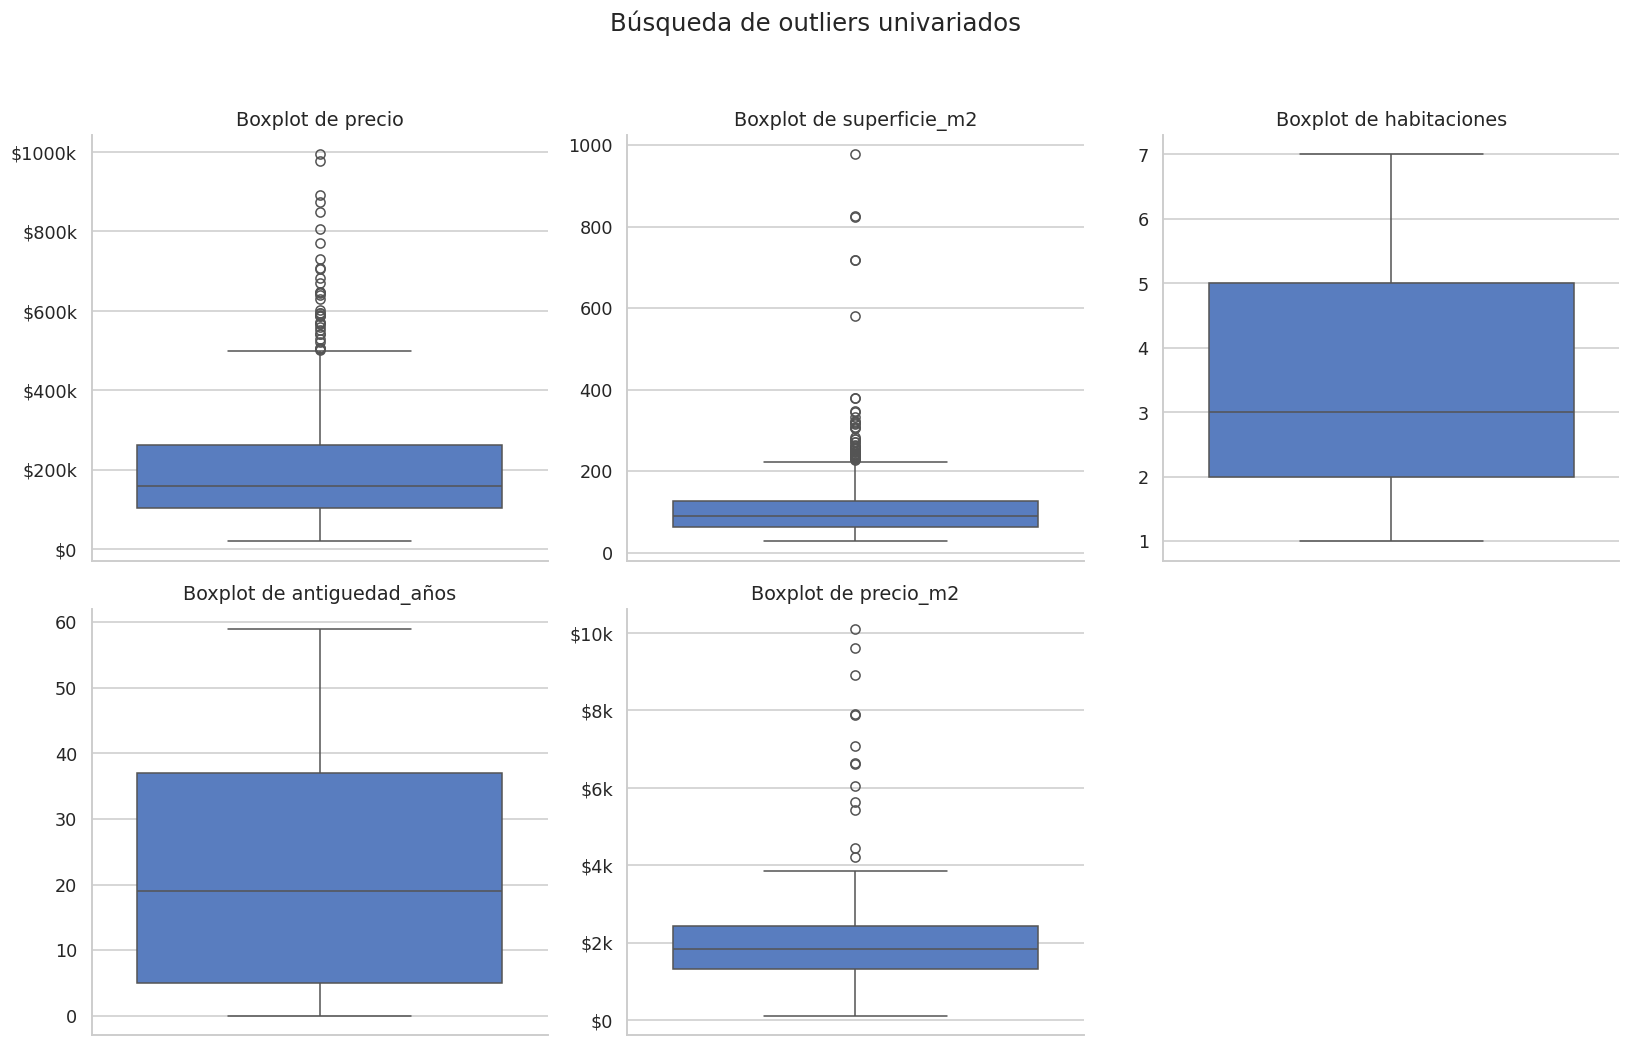

        precio  superficie_m2  habitaciones  antiguedad_años    barrio  \
122 169,600.00         719.00             2             5.00    Centro   
286 180,200.00         977.00             3            22.00    Centro   
290 185,600.00         827.00             3            28.00  Belgrano   
476  83,300.00         717.00             3            41.00       Sur   
482  93,100.00         581.00             3             2.00      Este   
705 102,400.00         823.00             1             1.00      Este   

     precio_m2 antiguedad_rango  
122     235.88        0-12 años  
286     184.44       12-24 años  
290     224.43       24-36 años  
476     116.18       36-48 años  
482     160.24        0-12 años  
705     124.42        0-12 años  


In [15]:
from matplotlib.ticker import FuncFormatter

# Seleccionar las columnas numéricas relevantes para los boxplots
# Excluimos 'id' ya que es un identificador y no una variable de análisis numérico para outliers.
# Ya hemos visto que 'precio_m2' es una derivada de 'precio' y 'superficie_m2',
# por lo que también la incluiremos.
numerical_cols = ['precio', 'superficie_m2', 'habitaciones', 'antiguedad_años', 'precio_m2']

def currency_formatter(x, pos):
    'The two args are the value and tick position'
    if x >= 1000:
        return '$%.0fk' % (x * 1e-3)
    else:
        return '$%.0f' % x

# Crear boxplots para cada columna numérica
plt.figure(figsize=(15, 10))
plt.suptitle('Búsqueda de outliers univariados', fontsize=16) # Main title for the figure
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i) # Ajusta el tamaño de la cuadrícula según el número de columnas
    sns.boxplot(y=dataset[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('') # Eliminar la etiqueta del eje y para evitar redundancia
    # Apply currency formatter to 'precio' and 'precio_m2' y-axis
    if col == 'precio' or col == 'precio_m2':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()
print(dataset[dataset['superficie_m2'] > 500].drop('id', axis=1))

Si bien existen valores por encima del bigote superior del boxplot de precio, no hay motivos particulares para creer que son irrisorios. No obstante, los valores de superficie por encima de 500 metros cuadrados despiertan cierta sospecha, de ahí que se los haya tabulado.

Para hacer un análisis más completo, se optó por realizar un scatter plot para evidenciar posibles outliers multivariados.

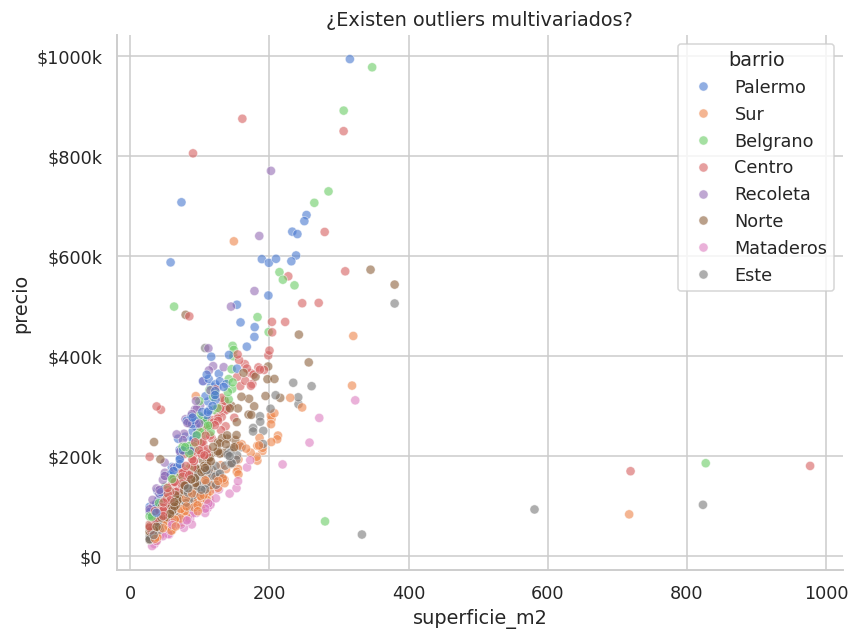

In [8]:
from matplotlib.ticker import FuncFormatter

numerical_cols = ['precio', 'superficie_m2', 'habitaciones', 'antiguedad_años', 'precio_m2']

# Crear scatter plots para pares de variables numéricas
# Esto ayudará a identificar outliers multivariados donde una combinación de valores es inusual.

# Seleccionar las combinaciones de variables solicitadas para visualizar
plot_combinations = [
    ('superficie_m2', 'precio')
]

def currency_formatter(x, pos):
    'The two args are the value and tick position'
    if x >= 1000:
        return '$%.0fk' % (x*1e-3)
    else:
        return '$%.0f' % x

plt.figure(figsize=(8, 6)) # Ajustar el tamaño para 1 plot
for i, (col1, col2) in enumerate(plot_combinations, 1):
    plt.subplot(1, 1, i) # Ajustar el tamaño de la cuadrícula a 1 fila, 1 columna
    sns.scatterplot(x=dataset[col1], y=dataset[col2], hue=dataset['barrio'], alpha=0.6) # Añadir 'hue' para diferenciar por barrio
    plt.title(f'¿Existen outliers multivariados?')
    plt.xlabel(col1)
    plt.ylabel(col2)
    if col2 == 'precio':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.tight_layout()
plt.show()

Como se aprecia en el gráfico, existen 4 propiedades por encima de 1000 metros cuadrados que cuestan menos de $400k, lo cual resulta aún más sospechoso cuando se consideran propiedades de menos superficie pero mayor costo en el mismo barrio. Por ello, se decidió eliminar esas 4 propiedades del análisis.

In [9]:
mask_outliers = (dataset['superficie_m2'] > 1000) & (dataset['precio'] < 400000)
dataset = dataset[~mask_outliers]

print(f"El dataset tiene {len(dataset)} elementos después de la limpieza de nulos y outliers.")

El dataset tiene 764 elementos después de la limpieza de nulos y outliers.


### 5. Relaciones entre variables

Con el dataset limpio, ya se puede encarar un análisis sobre cómo se vinculan las variables.

En primera instancia, ya se hizo alusión previamente a que `precio_m2` es una variable que resulta de operar con el *target*, lo cual incitaría a creer que ambos tienen una correlación lineal perfecta y, en consecuencia, se debería eliminar esta métrica. Sin embargo, dicho *feature* depende en simultáneo de otras variables para determinarse, por lo que la correlación no necesariamente será perfecta.

A continuación, se presenta la matriz de correlación de las variables numéricas para ilustrar lo planteado:

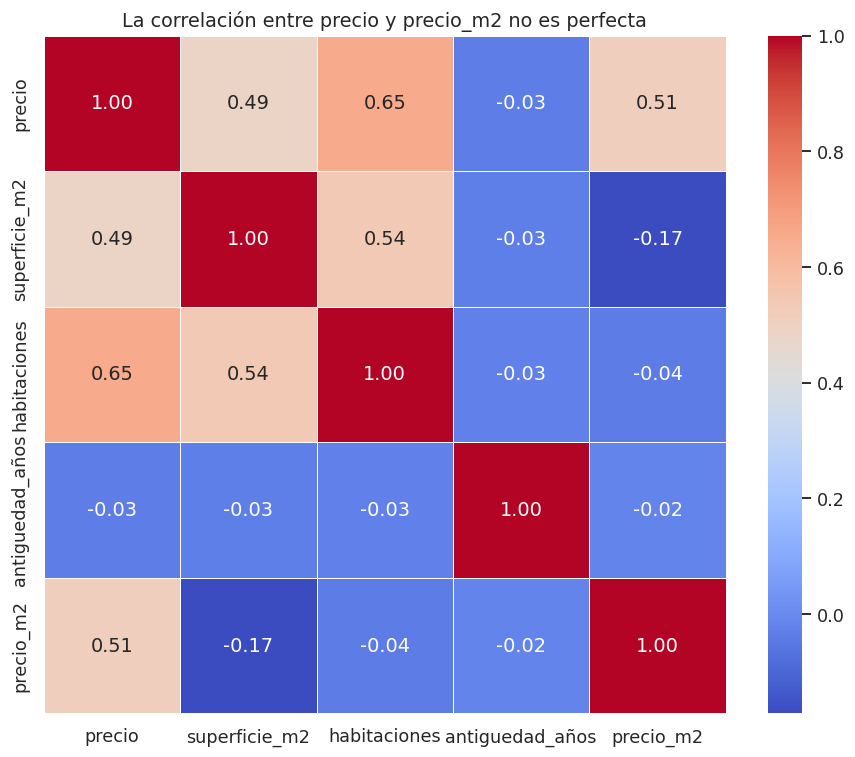

In [10]:
numerical_cols = ['precio', 'superficie_m2', 'habitaciones', 'antiguedad_años', 'precio_m2']
correlation_matrix = dataset[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('La correlación entre precio y precio_m2 no es perfecta')
plt.show()

Se evidencia en el gráfico que la hipótesis planteada es correcta, pues el precio en función de la superficie puede estar vinculado al barrio y/o la antigüedad. A su vez, el resto de correlaciones expuestas son esperables, exceptuando la de la antigüedad, que, por lo menos según esta métrica, no tiene injerencia en el precio.

In [11]:
from sklearn.feature_selection import mutual_info_regression

# Define numerical features (excluding 'id' and the target itself)
numerical_features = ['superficie_m2', 'habitaciones', 'antiguedad_años', 'precio_m2']
target = 'precio'

# Prepare data for mutual information calculation
X = dataset[numerical_features]
y = dataset[target]

# Calculate mutual information
mi_scores = mutual_info_regression(X, y, random_state=42)

# Create a Series for better display and sorting
mi_series = pd.Series(mi_scores, index=numerical_features).sort_values(ascending=False)

print("Información Mutua con el Target ('precio'):")
print(mi_series)

Información Mutua con el Target ('precio'):
superficie_m2     0.54
habitaciones      0.40
precio_m2         0.18
antiguedad_años   0.02
dtype: float64


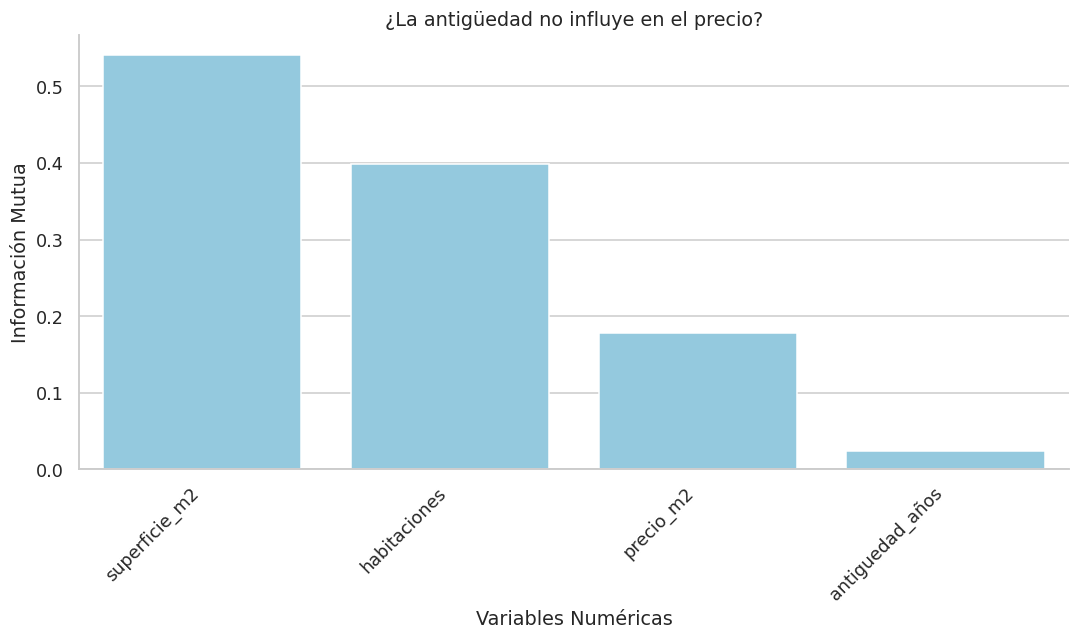

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.index, y=mi_series.values, color='skyblue') # Changed to single color
plt.title('¿La antigüedad no influye en el precio?')
plt.xlabel('Variables Numéricas')
plt.ylabel('Información Mutua')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Las métricas vuelven a señalar a la antigüedad como una variable que casi no se relaciona con el *target*, pero esto puede deberse, apelando a un análisis contextual, a que la forma en la que la antigüedad se correlaciona con el precio está guiada por una variable categórica: el barrio. Puede que, en ciertos barrios, una casa antigua no tenga un valor más bajo, sino que su cualidad de "propiedad histórica" eleve su precio. Al mismo tiempo, pueden haber otros factores no conisderados en este dataset que afecten el precio de una propiedad nueva, como la reputación de la constructora a cargo.

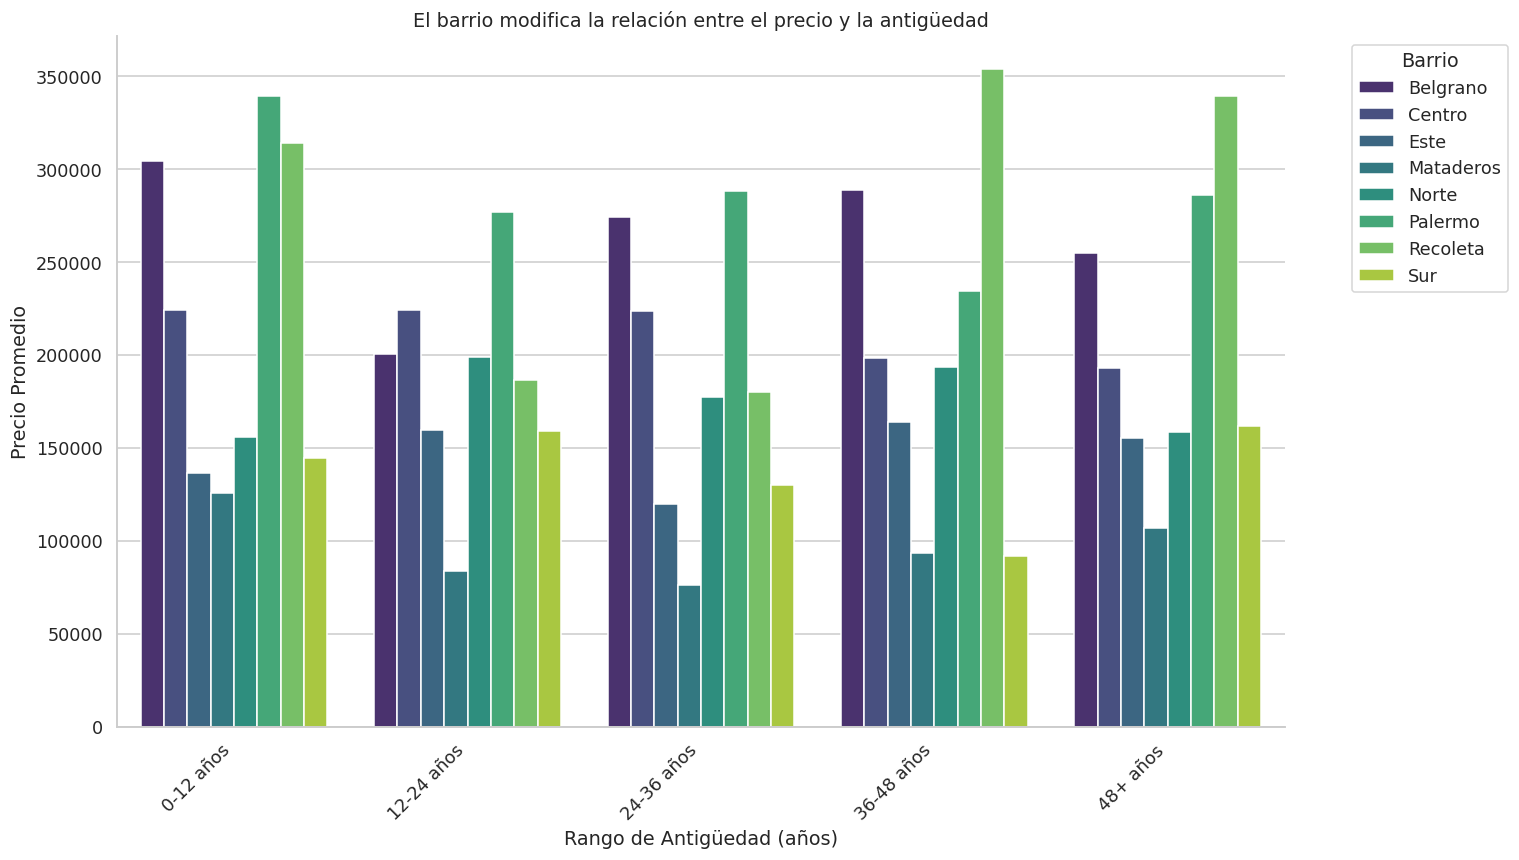

In [13]:
# Definir rangos de antigüedad
# Podemos usar pd.cut para crear estos rangos de manera conveniente
# Se eligen 5 bins para empezar, se pueden ajustar si es necesario
dataset['antiguedad_rango'] = pd.cut(dataset['antiguedad_años'],
                                     bins=5,
                                     labels=['0-12 años', '12-24 años', '24-36 años', '36-48 años', '48+ años'],
                                     include_lowest=True)

# Calcular la media de precios por barrio y rango de antigüedad
average_price_by_age_barrio = dataset.groupby(['barrio', 'antiguedad_rango'])['precio'].mean().reset_index()

# Crear el gráfico
plt.figure(figsize=(14, 8))
sns.barplot(data=average_price_by_age_barrio,
            x='antiguedad_rango',
            y='precio',
            hue='barrio',
            palette='viridis')

plt.title('El barrio modifica la relación entre el precio y la antigüedad')
plt.xlabel('Rango de Antigüedad (años)')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

En el gráfico anterior queda claro que, dependiendo del barrio que se observe, el precio relativo a la antigüedad fluctúa, por lo que no puede asumirse que la misma no se correlaciona con el target.

### 6. Conclusiones

Como corolario del análisis realizado sobre el dataset, se puede aducir que la mayoría de las variables se vinculan con el precio y, además, casi todas presentan una correlación lineal, con la antigüedad como única excepción; sobre esta misma variable, resulta relevante notar que, si bien las métricas tradicionales señalaron que no se vinculaba al target, métricas multivariadas y parte de análisis de contexto permitieron entender por qué no se debería descartar esta variable de plano, al menos hasta ver cómo se desempeña un modelo que se entrene con esos datos.

Sobre la variable precio_m2, cabe mencionar que es un buen ejemplo de variable que, si bien es el resultado de la operación matemática entre otras variables (donde una de ellas es el target), eso no implica que la correlación con el objetivo es perfecta, mucho menos que vaya a disminuir gravemente la calidad del entrenamiento.

## Ejercicio N°2 - Exploración comparativa
Para este ejercicio se incorpora un segundo dataset, correspondiente al historial de clientes de una
empresa de telecomunicaciones con información sobre cancelación del servicio (churn). El dataset incluye
variables como antigüedad del cliente, tipo de contrato, monto mensual facturado, cantidad de productos
contratados y una variable binaria que indica si el cliente abandonó el servicio (churn: 0 = permanece,
1 = se fue).

### 1. Carga y Vista Inicial
A modo de comparación se presentan algunas instancias de los datasets de churn y propiedades.




In [ ]:
propiedades = pd.read_csv("propiedades.csv")
churn = pd.read_csv("clientes_churn.csv")

In [ ]:
print("Propiedades:")
display(propiedades.head())

print("\nChurn:")
display(churn.head())

Propiedades:


,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,"648,900.00",232.90,6,5.00,Palermo,"2,786.17"
1,2,"210,000.00",190.10,6,1.00,Sur,"1,104.68"
2,3,"254,800.00",103.60,4,18.00,Belgrano,"2,459.46"
3,4,"594,000.00",189.20,6,4.00,Palermo,"3,139.53"
4,5,"170,200.00",90.60,2,45.00,Centro,"1,878.59"



Churn:


,id_cliente,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,1001,42,anual,40.64,3.00,1,1,0
1,1002,16,mensual,68.57,2.00,1,0,1
2,1003,78,bianual,32.38,3.00,0,0,1
3,1004,9,anual,63.87,1.00,0,1,1
4,1005,1,mensual,68.47,1.00,1,1,0


### Propiedades de los datasets.

Se listan las propiedades de los datasets a modo de comprender qué tipos de datos se deben almacenar en cada caso y su tamaño.



In [ ]:
print("Propiedades info:")
propiedades.info()

print("\nChurn info:")
churn.info()

Propiedades info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB

Churn info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           1200 non-null   int64  
 1   antiguedad_meses     1200 non-null   int64  
 2   contrato             1200 non-null   object 
 3   facturacion_mensual  1164 n

Hay variables cuya representación en pandas podría ajustarse para reflejar mejor su naturaleza analítica.

**"churn"**, **"soporte técnico"** y **"tiene fibra"**: Son de tipo booleano pero está cargado como un int64.

**"productos"**: Es de tipo entero positivo pero  está guardado como float64.

**"contrato"**: Es un string pero está cargado como objeto, de igual forma se le aplica un encoding volviendolo un valor entero.

Todos estos errores en la interpretación de los tipos de datos implica un desperdicio de recursos.


In [ ]:
print("Nulos en propiedades:")
print(propiedades.isnull().sum())

print("\nNulos en churn:")
print(churn.isnull().sum())

Nulos en propiedades:
id                  0
precio             32
superficie_m2       0
habitaciones        0
antiguedad_años    48
barrio              0
precio_m2          32
dtype: int64

Nulos en churn:
id_cliente              0
antiguedad_meses        0
contrato                0
facturacion_mensual    36
productos              60
soporte_tecnico         0
tiene_fibra             0
churn                   0
dtype: int64


El dataset de churn posee mas variables categoricas lo cual lo hace un poco mas complicado a la hora de analizar las relaciones entre las variables, sin embargo el target al ser de tipo "True" o "False" y no poseer tanto desbalance se hace mas fácil de predecir.

Por otra parte el dataset de propiedades parece ligeramente más limpio en términos de faltantes relativos en algunas variables clave, pero presenta una variable derivada (**precio_m2**) y un target continuo (**precio**) que vuelven más delicada la interpretación exploratoria.

Con respecto al tamaño, el dataset de propiedades es menor en tamaño al de la empresa de telecomunicaciones, menos datos que procesar implica un menor trabajo para el modelo a entrenar.

### Visualización de la distribución de variables categóricas

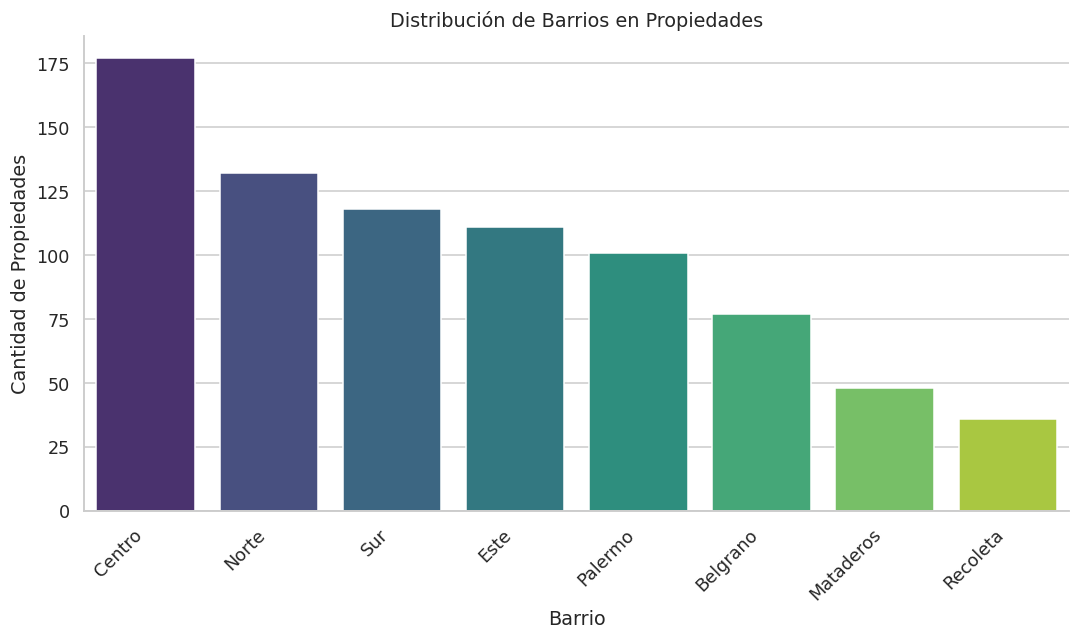

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=propiedades, x='barrio', palette='viridis', order=propiedades['barrio'].value_counts().index)
plt.title('Distribución de Barrios en Propiedades')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de Propiedades')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

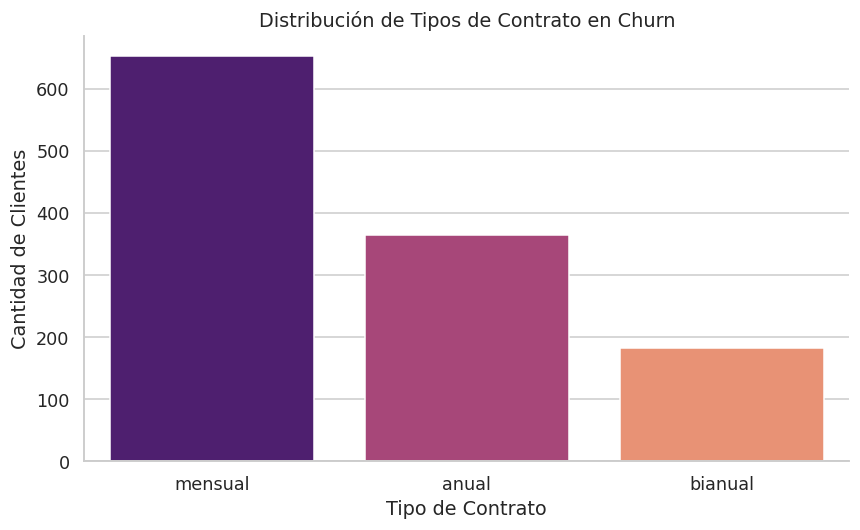

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=churn, x='contrato', palette='magma', order=churn['contrato'].value_counts().index)
plt.title('Distribución de Tipos de Contrato en Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()



*   Distribución de barrio: La variable barrio presenta una distribución relativamente equilibrada. Aunque hay ligeras variaciones, ningún barrio domina de manera abrumadora. Esto sugiere que el dataset abarca una diversidad de ubicaciones sin un sesgo geográfico pronunciado, lo cual es positivo para análisis que busquen generalizar patrones en distintas zonas.


*   Distribución de contrato: La variable contrato muestra una clara predominancia del tipo de contrato 'mensual', que representa la mitad de los clientes. Los contratos 'anual' y 'bianual' tienen una proporción similar entre sí, pero significativamente menor que los mensuales. Esta observación es crucial, ya que el tipo de contrato podría ser un factor importante en la decisión de abandono del servicio. Los clientes con contratos mensuales, al tener menos compromiso a largo plazo, podrían ser más propensos al churn.



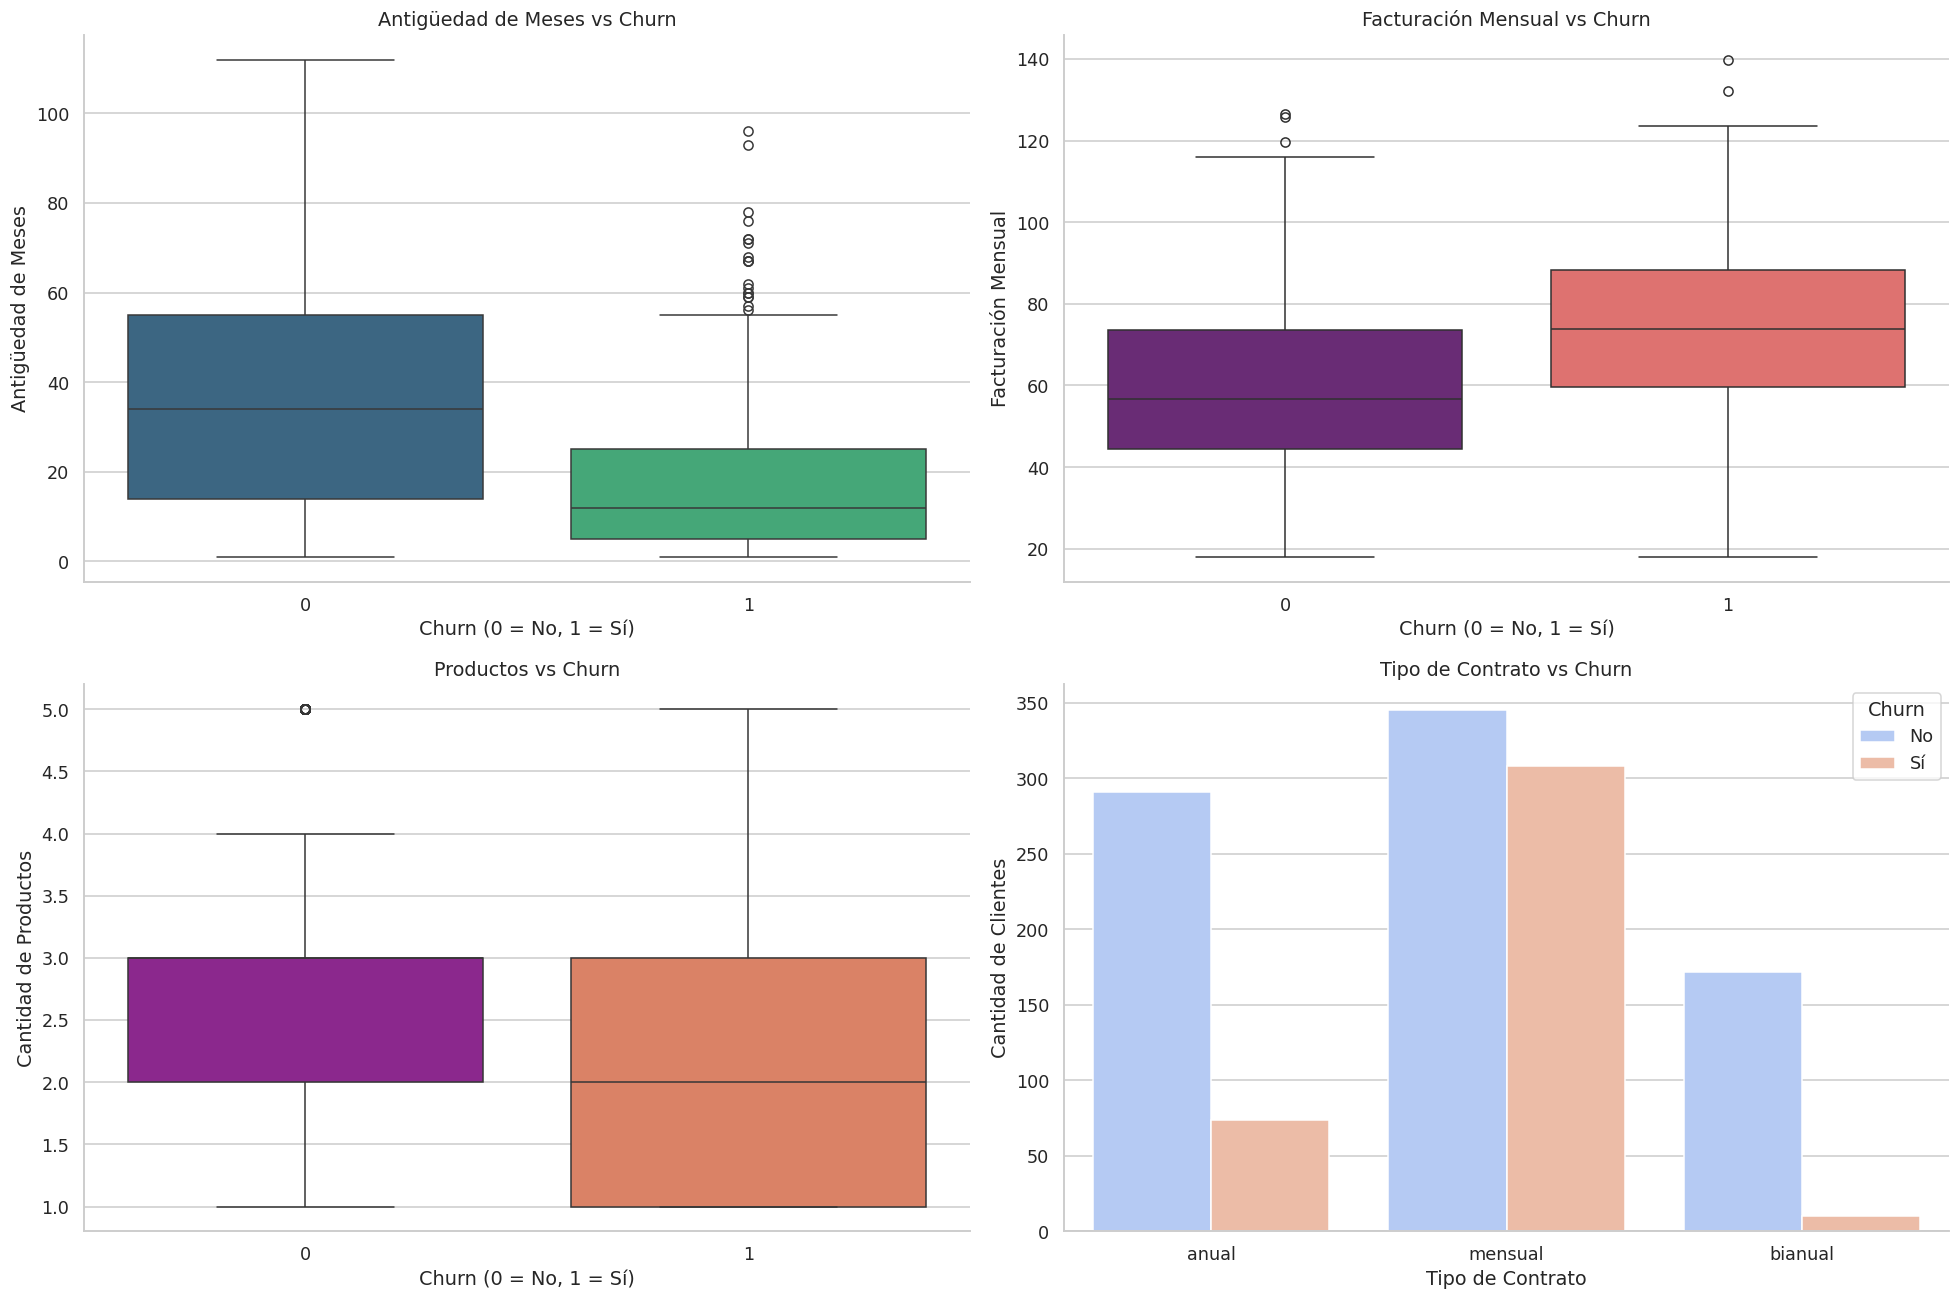

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

# Box plot for antiguedad_meses vs churn
plt.subplot(2, 2, 1)
sns.boxplot(data=churn, x='churn', y='antiguedad_meses', palette='viridis')
plt.title('Antigüedad de Meses vs Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Antigüedad de Meses')

# Box plot for facturacion_mensual vs churn
plt.subplot(2, 2, 2)
sns.boxplot(data=churn, x='churn', y='facturacion_mensual', palette='magma')
plt.title('Facturación Mensual vs Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Facturación Mensual')

# Box plot for productos vs churn
plt.subplot(2, 2, 3)
sns.boxplot(data=churn, x='churn', y='productos', palette='plasma')
plt.title('Productos vs Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Productos')

# Count plot for contrato vs churn (as contrato is categorical)
plt.subplot(2, 2, 4)
sns.countplot(data=churn, x='contrato', hue='churn', palette='coolwarm')
plt.title('Tipo de Contrato vs Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()



*   Al comparar **antiguedad_meses** según **churn**, se observa un corrimiento hacia valores más bajos en quienes abandonaron el servicio. Esto sugiere que el riesgo de churn es mayor en clientes recientes, posiblemente porque aún no consolidaron fidelidad con la empresa.
*   En facturacion_mensual, los clientes con churn parecen presentar una distribución algo más desplazada hacia valores altos, lo que permitiría hipotetizar que un mayor costo mensual incrementa la probabilidad de abandono.
*   En la comparacion de cantidad de productos respecto de churn se aprecia que los clientes con menos cantidad de productos son lo que optan por finalizar el servicio.
*   El gráfico de barras muestra la cantidad de clientes según el tipo de contrato. Se observa que el contrato mensual concentra la mayor cantidad de clientes, seguido por el anual y, en menor medida, el bianual. Asi mismo se observa en distintos colores la cantidad de esos clientes que dejaron y no dejaron el servicio, existiendo una relacion importante entre el plan mensual y la cantidad de clientes que abandonan el servicio




### Variables categóricas y desbalance de clases

Vamos a identificar las variables categóricas y analizar su distribución, así como el balance de clases en el dataset de `churn`.

In [ ]:
# Identificar variables categóricas y verificar su distribución en 'propiedades'
print("Distribución de la variable 'barrio' en propiedades:")
display(propiedades['barrio'].value_counts(normalize=True))

# Identificar variables categóricas y verificar su distribución en 'churn'
print("\nDistribución de la variable 'contrato' en churn:")
display(churn['contrato'].value_counts(normalize=True))

Distribución de la variable 'barrio' en propiedades:


,proportion
barrio,
Centro,0.22
Norte,0.17
Sur,0.15
Este,0.14
Palermo,0.13
Belgrano,0.10
Mataderos,0.06
Recoleta,0.04



Distribución de la variable 'contrato' en churn:


,proportion
contrato,
mensual,0.54
anual,0.30
bianual,0.15


#### Análisis de desbalance en el dataset de churn

Vamos a verificar si las clases de la variable `churn` están balanceadas y calcular la proporción de clientes que abandonaron el servicio.

Distribución de la variable objetivo (churn):


,Cantidad,Porcentaje (%)
churn,,
0,808,67.33
1,392,32.67


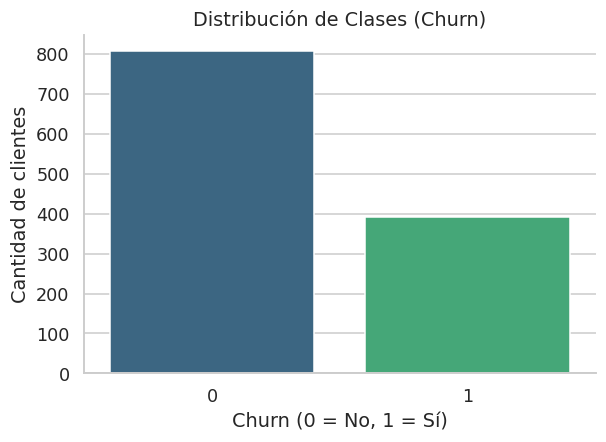

In [ ]:
# Contar las ocurrencias de cada clase en la variable 'churn'
conteo_churn = churn['churn'].value_counts()
porcentajes_churn = churn['churn'].value_counts(normalize=True) * 100

# Crear un DataFrame para visualizar
resumen_churn_balance = pd.DataFrame({
    'Cantidad': conteo_churn,
    'Porcentaje (%)': porcentajes_churn
})

print("Distribución de la variable objetivo (churn):")
display(resumen_churn_balance)

# Visualización del desbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=churn, x='churn', palette='viridis')
plt.title('Distribución de Clases (Churn)')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de clientes')
plt.show()

El 67.33% de los clientes no abandono, el resto si lo hizo.
Si hubiera un desbalance mayor, accuracy dejaría de ser confiable como métrica principal, ya que un modelo podría acertar mucho prediciendo siempre la clase mayoritaria. En ese escenario convendría priorizar precision, recall, F1-score, matriz de confusión, ROC-AUC y especialmente PR-AUC si la clase positiva fuera minoritaria y relevante


### Observaciones del Pairplot de Churn:

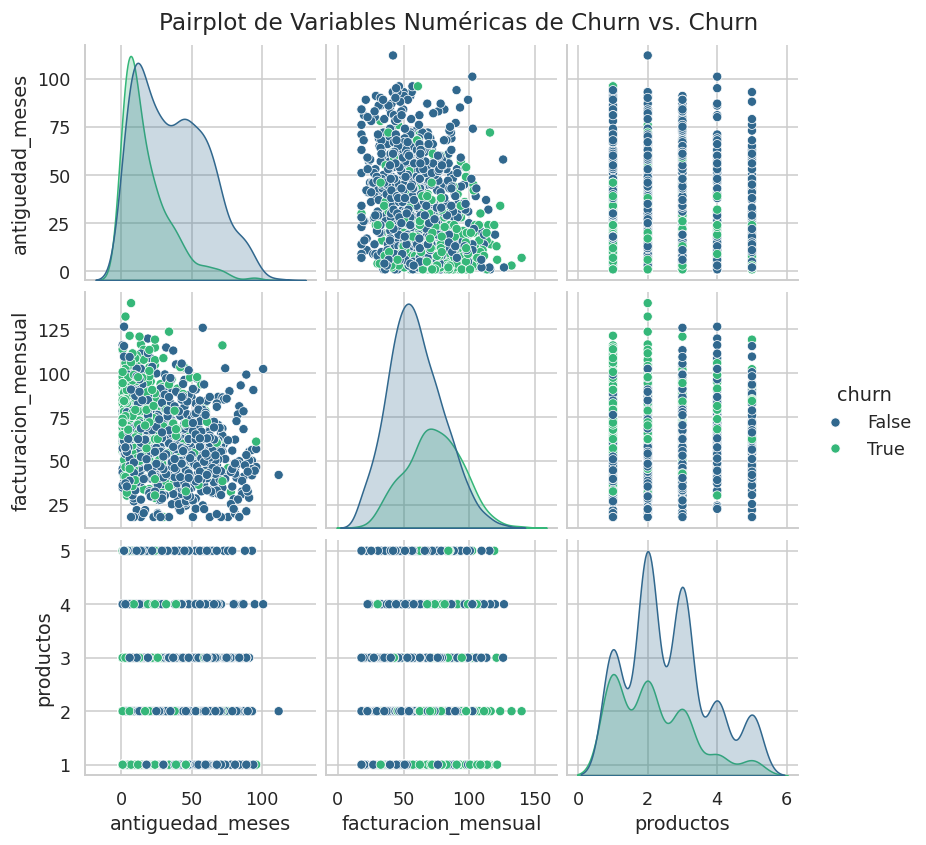

In [ ]:
# Pairplot para el dataset 'churn' (seleccionando variables numéricas clave) coloreando por 'churn'
# Para evitar un pairplot excesivamente denso, seleccionamos las variables numéricas más relevantes
churn_numeric_cols = ['antiguedad_meses', 'facturacion_mensual', 'productos']

sns.pairplot(churn, vars=churn_numeric_cols, hue='churn', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot de Variables Numéricas de Churn vs. Churn', y=1.02) # Ajustar el título para que no se solape
plt.show()

**Observaciones del Pairplot de Churn:**

El `pairplot` nos permite visualizar la distribución de cada variable numérica y sus relaciones bivariadas, diferenciando por la variable `churn`.

*   **`antiguedad_meses` vs. `churn`**: No se observa una separación perfecta entre clases, pero antiguedad_meses muestra una tendencia clara: los clientes con menor antigüedad concentran mayor proporción de churn. La variable contrato, especialmente al distinguir mensual frente a anual/bianual, también parece aportar capacidad discriminativa.
*   **`facturacion_mensual` vs. `churn`**: La separación es nítida, pero se puede ver una tendencia. Los clientes con `churn=1` (verde) parecen tener una `facturacion_mensual` ligeramente más alta en promedio o con una distribución más dispersa hacia valores mayores, aunque hay solapamiento significativo. Esto sugiere que una facturación alta por sí sola no es el único factor, pero podría contribuir si no se percibe un valor adecuado.
*   **`productos` vs. `churn`**: Hay cierta separación. Los clientes que *no* hacen churn (azul) parecen tener un número de `productos` ligeramente mayor o una distribución más concentrada en 2-3 productos, mientras que los que *sí* hacen churn (verde) pueden estar más concentrados en 1-2 productos. Esto podría indicar que a mayor número de productos contratados, mayor lealtad, o que la falta de oferta adecuada contribuye al churn.
*   **Combinaciones de Variables**: Las dispersiones entre pares de variables (por ejemplo, `antiguedad_meses` vs. `facturacion_mensual` coloreado por `churn`) no muestran una separación lineal perfecta, pero la concentración de puntos verdes (churn) en regiones de baja `antiguedad_meses` y a veces alta `facturacion_mensual` sugiere que estas combinaciones de características son importantes. No hay una combinación de dos variables que separe *perfectamente* las clases de forma visual, lo que indica que el problema es multivariado.

### Correlaciones y Encoding

Se analiza la matriz de correlacion entre todas las variables predictoras y el target, a su vez se realiza un encoding de la variable "Contratos" con el siguiente criterio

**Mensual = 0**

**Anual = 1**

**Bianual = 2**

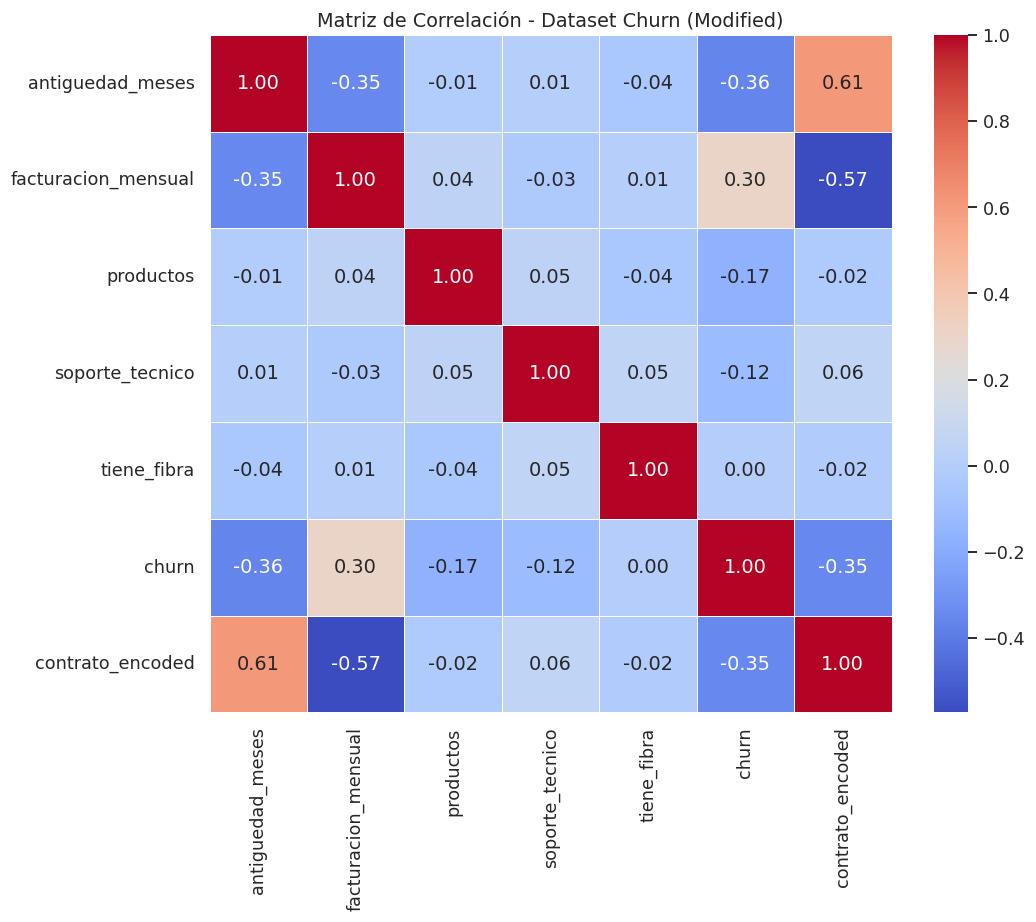

Correlación con la variable objetivo (churn) en el dataset modificado:
churn                  1.00
facturacion_mensual    0.30
tiene_fibra            0.00
soporte_tecnico       -0.12
productos             -0.17
contrato_encoded      -0.35
antiguedad_meses      -0.36
Name: churn, dtype: float64


In [ ]:
# Create a copy of the churn DataFrame for this analysis
churn_for_corr = churn.copy()

# Drop 'id_cliente' as requested
if 'id_cliente' in churn_for_corr.columns:
    churn_for_corr = churn_for_corr.drop(columns=['id_cliente'])

# Apply ordinal encoding to 'contrato' column
# Assigning a logical order: mensual (short-term) -> anual -> bianual (long-term)
contract_mapping = {'mensual': 0, 'anual': 1, 'bianual': 2}
churn_for_corr['contrato_encoded'] = churn_for_corr['contrato'].map(contract_mapping)

# Drop the original 'contrato' column as it's now encoded
churn_for_corr = churn_for_corr.drop(columns=['contrato'])

# Calcular la matriz de correlación para el dataset churn modificado
churn_corr_matrix_modified = churn_for_corr.corr(numeric_only=True)

# Visualizar con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(churn_corr_matrix_modified, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Churn (Modified)')
plt.show()

# Mostrar específicamente la correlación con el target 'churn'
print("Correlación con la variable objetivo (churn) en el dataset modificado:")
print(churn_corr_matrix_modified['churn'].sort_values(ascending=False))

Los datos de la matriz de correlación concuerdan bastante con la realidad, tipo de contrato, productos, facturación mensual y antiguedad tienen relación con la tasa de abandono.


### Información mutua

Se analizará la información mutua entre las variables predictoras con respecto al target, con el fin de comprender si existen relaciones no lineales con el target (churn).

Mutual Information Scores (Higher is more informative for Churn):


,0
antiguedad_meses,0.08
contrato_encoded,0.07
facturacion_mensual,0.03
productos,0.03
soporte_tecnico,0.00
tiene_fibra,0.00


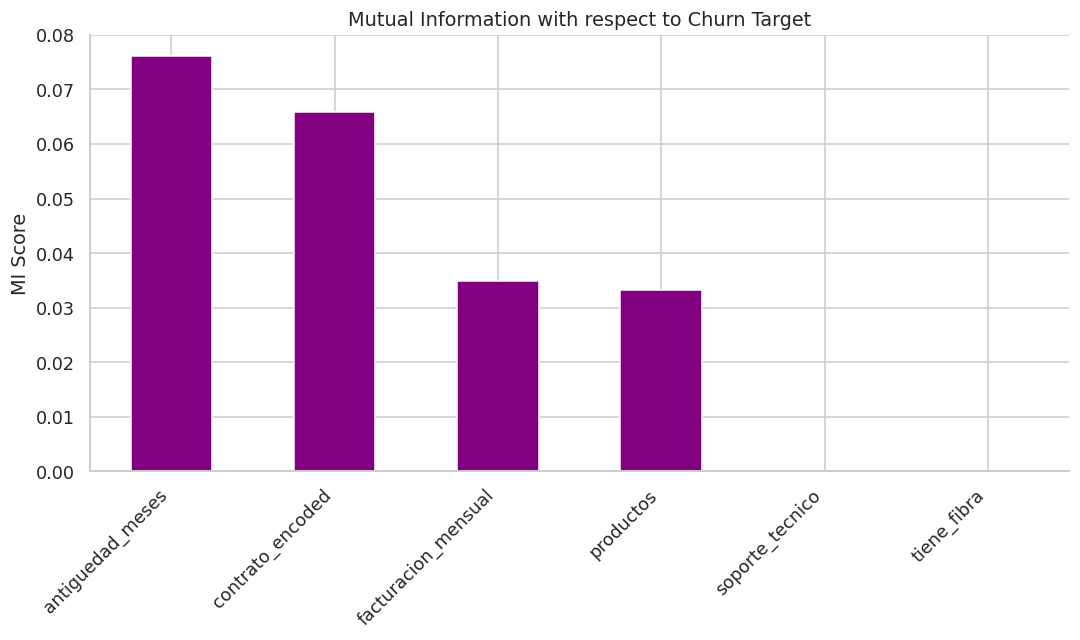

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the churn DataFrame for this analysis
churn_for_mi = churn.copy()

# Drop 'id_cliente' as it's an identifier and not a predictor
if 'id_cliente' in churn_for_mi.columns:
    churn_for_mi = churn_for_mi.drop(columns=['id_cliente'])

# Apply ordinal encoding to 'contrato' column
# Assigning a logical order: mensual (short-term) -> anual -> bianual (long-term)
contract_mapping = {'mensual': 0, 'anual': 1, 'bianual': 2}
churn_for_mi['contrato_encoded'] = churn_for_mi['contrato'].map(contract_mapping)

# Drop the original 'contrato' column as it's now encoded
churn_for_mi = churn_for_mi.drop(columns=['contrato'])

# Handle missing values for mutual information calculation
# mutual_info_classif does not support NaNs, so we drop rows for this calculation
churn_for_mi_clean = churn_for_mi.dropna()

X_mi = churn_for_mi_clean.drop(columns=['churn'])
y_mi = churn_for_mi_clean['churn']

# Calculate Mutual Information
# Ensure all columns in X_mi are numeric for mutual_info_classif
X_mi = X_mi.select_dtypes(include=np.number)
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

# Create a Series for visualization
mi_results = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print("Mutual Information Scores (Higher is more informative for Churn):")
display(mi_results)

# Plotting the scores
plt.figure(figsize=(10, 6))
mi_results.plot(kind='bar', color='purple')
plt.title('Mutual Information with respect to Churn Target')
plt.ylabel('MI Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Teniendo en cuenta los resultados de la matriz de correlacion y la de información mutua se puede concluir que las variables "soporte técnico" y "tiene fibra " no tienen mucha influencia en si el cliente dejará o no de utilizar el servicio.
Lo que más afecta en predecir la tasa de abandono es la antiguedad del cliente y el tipo de contrato que tiene, un cliente que tiene un contrato bianual con mucha antiguedad es muy poco probable que deje de utilizar el servicio. Por otro lado si la facturación es excesiva y la cantidad de productos que ofrece la empresa es baja, es muy probable que aparezca competencia que ofrezca mas productos a un menor precio, lo cual da el impulso al cliente de abandonar el servicio.

## Ejercicio N°3  – Exploración de datos en ausencia de contexto

---



### **Comprensión estructural del dataset**
En este ejercicio se introduce un dataset “desconocido”, en el que la relación entre las
variables y el target es presuntamente no lineal y no resulta evidente a priori.
El dataset contiene múltiples variables numéricas, algunas de las cuales son relevantes para predecir el
target y otras son ruido puro. Además, existen valores faltantes y outliers. La variable objetivo (target) es
binaria (0 o 1). El dataset se encuentra en el archivo adjunto denominado “dataset_desconocido.csv”. En
la Tabla 3, se presenta un fragmento representativo.


In [ ]:
df = pd.read_csv("dataset_desconocido.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n")
print("Primeras filas:")
df.head(10)

Dimensiones del dataset: 1000 filas × 7 columnas

Primeras filas:


,x1,x2,x3,x4,x5,x6,target
0,-2.11,1.86,-1.20,0.81,0.67,-0.40,0
1,0.01,-1.05,-0.75,-0.38,-1.38,-0.12,1
2,5.40,-5.65,-0.80,-1.73,-1.72,-1.52,1
3,1.04,-0.14,0.18,-1.26,-1.34,0.75,1
4,-1.00,-1.73,1.53,-1.94,0.81,0.15,0
5,-0.17,0.86,0.97,-1.69,0.39,0.33,1
6,NaN,-0.02,1.97,-0.34,1.25,0.64,1
7,-0.82,2.58,-1.33,0.62,-0.38,-0.64,0
8,5.19,3.86,5.45,-0.31,0.67,-1.36,1
9,8.07,-5.41,0.62,-0.64,-2.20,1.04,0


Dado que son datos "sueltos" y se desconoce qué representa el target y las variables,intentar buscar patrones o correlaciones entre las variables que indique cuándo el target es 0 o 1.

### **Datos faltantes y imputación**

In [ ]:
faltantes = df.isnull().sum()
pct_faltantes = (faltantes / len(df) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "Cantidad": faltantes,
    "Porcentaje (%)": pct_faltantes
}).query("Cantidad > 0")

print("Variables con valores faltantes:")
print(resumen_faltantes)


Variables con valores faltantes:
    Cantidad  Porcentaje (%)
x1        19            1.90
x2        13            1.30
x3        18            1.80


Debido a que se desconoce la naturaleza de los datos, no se realiza una imputación de los mismos. Cabe destacar que x4, x5 y x6 no poseen datos faltantes.

### **Balanceo**

Se realizó un análisis de distribución sobre la variable objetivo (target) para evaluar un posible desbalance de clases, condición característica de eventos de baja frecuencia como fallos críticos o tareas de mantenimiento. Dada la naturaleza puramente numérica de los predictores, se postula —a modo de ejemplo ilustrativo— que podrían representar señales de sensores cuya configuración determine la activación de un actuador, aunque la semántica real de los datos permanece bajo estudio.

Distribución de la variable objetivo (target):


,Cantidad,Porcentaje (%)
target,,
0,554,55.40
1,446,44.60


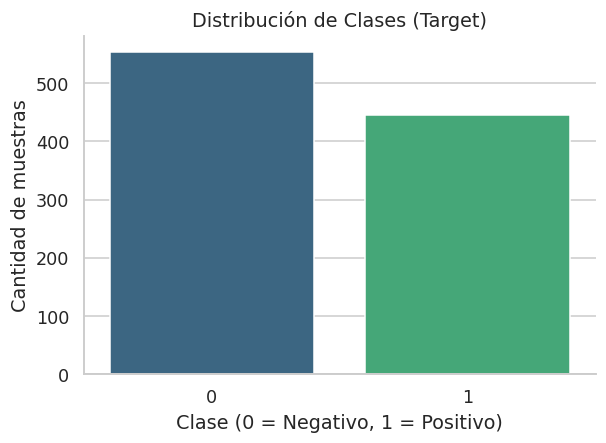

In [ ]:
# Contar las ocurrencias de cada clase en el target
conteo_clases = df['target'].value_counts()
porcentajes = df['target'].value_counts(normalize=True) * 100

# Crear un DataFrame para visualizar
resumen_balance = pd.DataFrame({
    'Cantidad': conteo_clases,
    'Porcentaje (%)': porcentajes
})

print("Distribución de la variable objetivo (target):")
display(resumen_balance)

# Visualización
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='viridis')
plt.title('Distribución de Clases (Target)')
plt.xlabel('Clase (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad de muestras')
plt.show()

En el gráfico de barras se aprecia que no existe desbalance entre la clase 1 y 0.

### Tipos de datos

In [ ]:
print("Tipos de datos por columna:")
print(df.dtypes)

Tipos de datos por columna:
x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
x6        float64
target      int64
dtype: object


Los 6 atributos de la tabla son de tipo flotante en formato de doble precision, a su vez el target es de tipo int, lo cual es un desperdicio de espacio teniendo en cuenta que en la premisa target representa un "True (1)" o "False (0)".

## **Cálculo de estadísticos**
Si bien se carece de contexto se calculan los estadísticos de todas las variables, a modo de entender mejor la distribución que siguen los datos.

In [ ]:
# Calculate main statistics for features x1 to x6
stats_features = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']].describe().T

# Adding median explicitly (it is the same as 50%)
stats_features['median'] = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']].median()

print("Estadísticos descriptivos para x1-x6:")
display(stats_features)

Estadísticos descriptivos para x1-x6:


,count,mean,std,min,25%,50%,75%,max,median
x1,981.00,-0.01,2.40,-7.69,-1.37,0.01,1.33,12.11,0.01
x2,987.00,-0.04,2.25,-9.27,-1.39,0.03,1.34,9.13,0.03
x3,982.00,0.03,1.84,-7.67,-1.07,-0.01,1.02,7.18,-0.01
x4,"1,000.00",0.05,1.01,-4.39,-0.63,0.07,0.72,3.24,0.07
x5,"1,000.00",-0.00,1.03,-3.06,-0.66,-0.06,0.72,3.21,-0.06
x6,"1,000.00",-0.03,0.98,-3.02,-0.66,-0.06,0.62,3.29,-0.06


### Distruciones de las variables predictoras
En los graficos se observa como de distribuye cada variable con respecto a las clases 0 y 1. Analizando los estadísticos vemos que la distribución de los datos es aproximadamente uniforme, lo cual concuerda con las graficas de tipo campana de gauss.

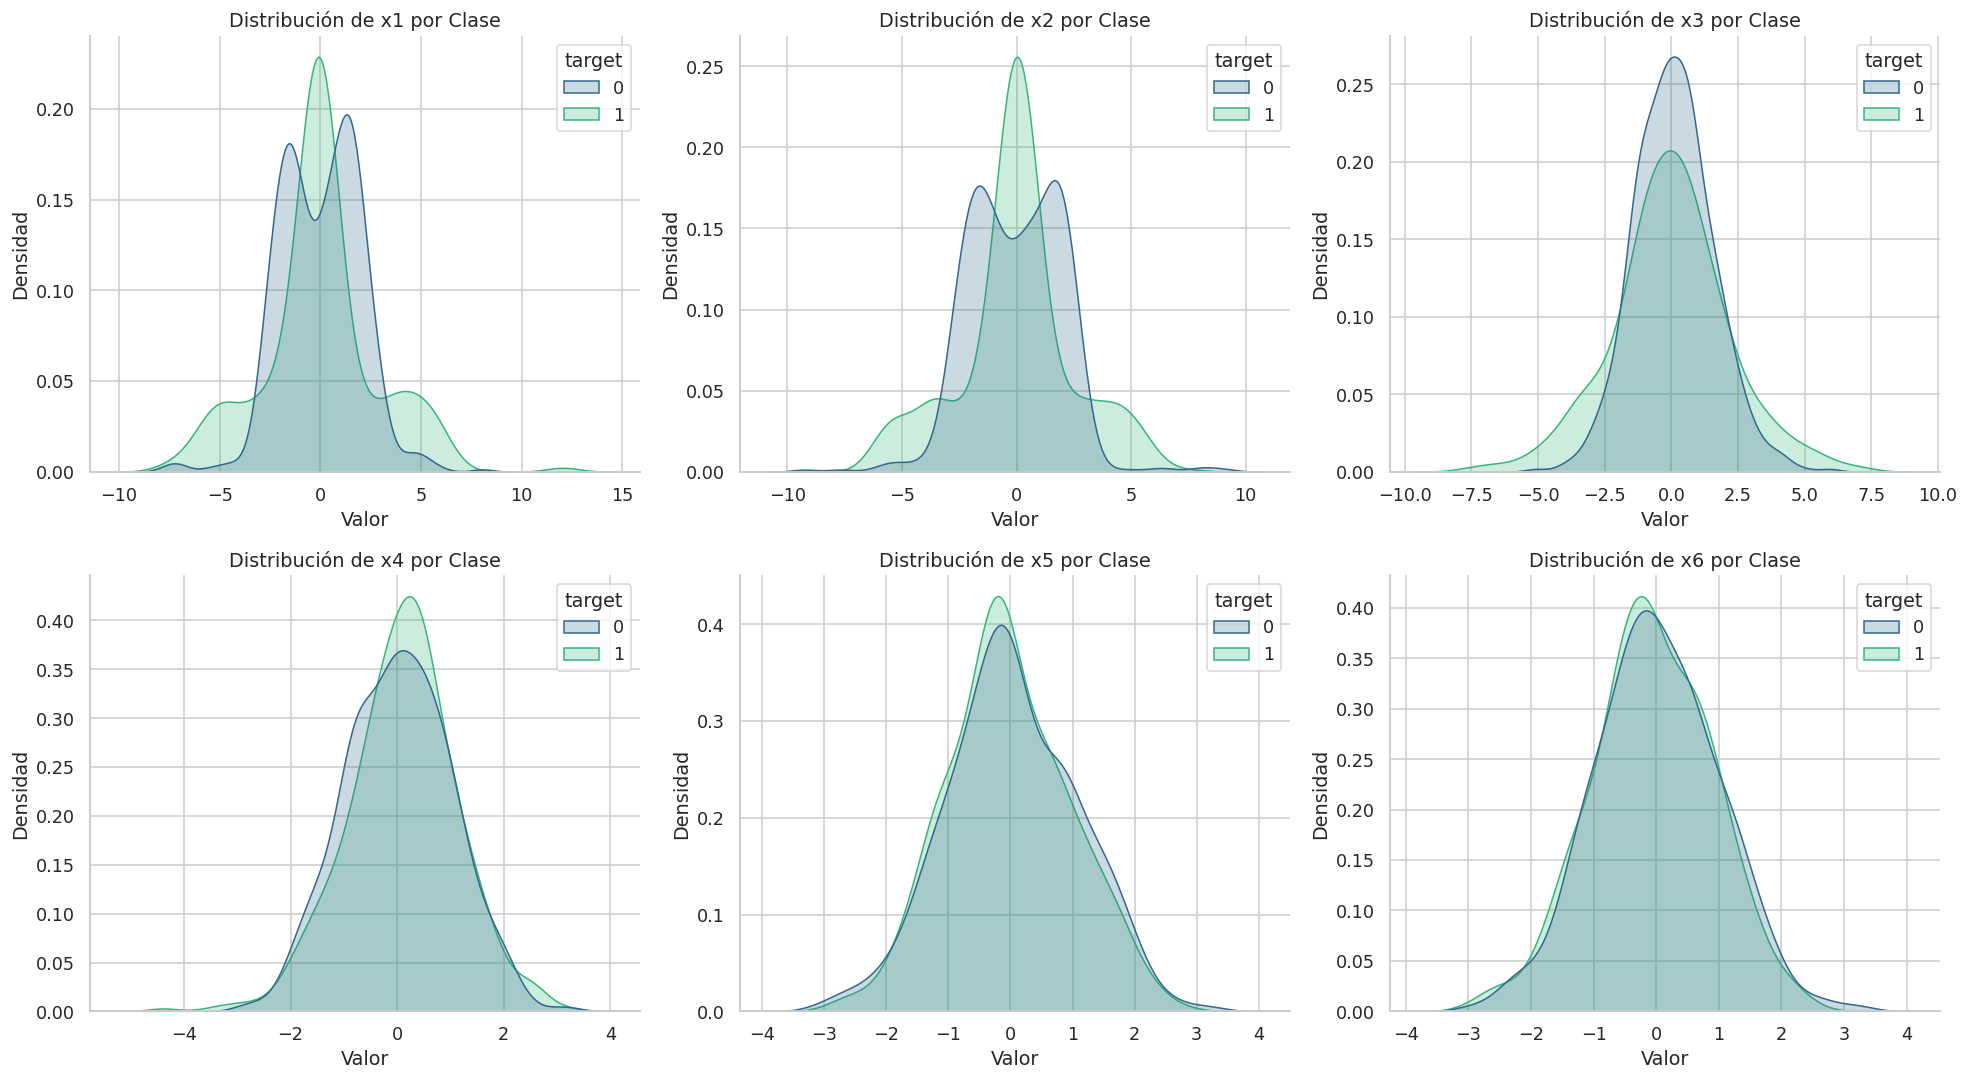

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to plot
features = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

# Create a figure with a grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='target', fill=True, common_norm=False, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribución de {col} por Clase')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

### Correlaciones entre las variables

A modo de primer vistazo se analiza la correlación lineal entre todas las variables entre si y con el target.

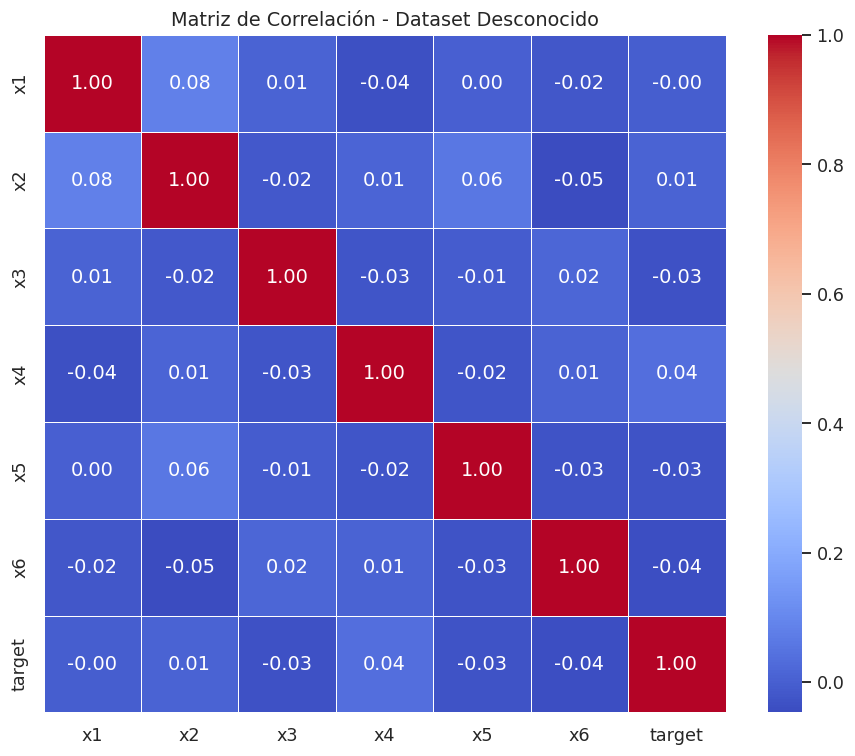

Correlación con la variable objetivo (target):
target    1.00
x4        0.04
x2        0.01
x1       -0.00
x5       -0.03
x3       -0.03
x6       -0.04
Name: target, dtype: float64


In [ ]:
# Calcular la matriz de correlación
corr_matrix = df.corr()

# Visualizar con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Desconocido')
plt.show()

# Mostrar específicamente la correlación con el target
print("Correlación con la variable objetivo (target):")
print(corr_matrix['target'].sort_values(ascending=False))

La matriz de correlación lineal no mostró ninguna relación entre las features de nuestro sistema. Esto no necesariamente significa que no exista una relación entre las variables, sino que puede existir una relación no lineal.

### Relaciones no lineales

Se propone analizar la información mutua de las distintas variables predictoras con respecto al target para observar si existe algún patrón.

Mutual Information Scores (Higher is more informative):


,0
x1,0.14
x2,0.12
x3,0.04
x6,0.01
x4,0.00
x5,0.00


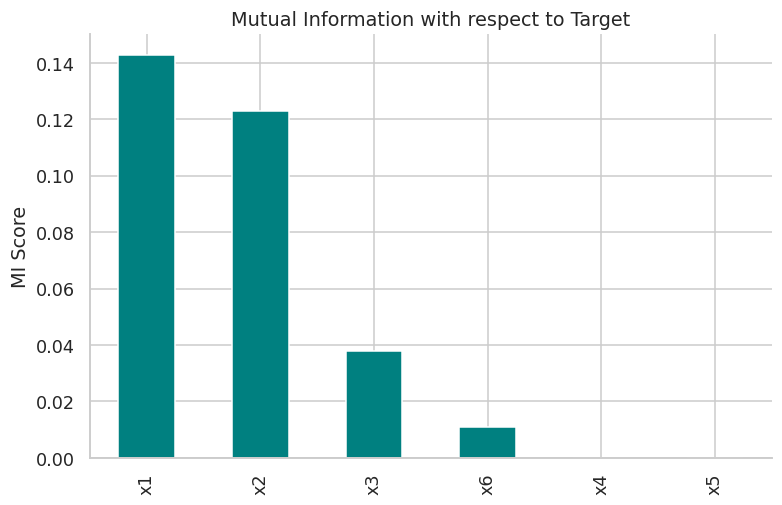

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Prepare data by dropping rows with NaN for the MI calculation
df_clean = df.dropna()
X = df_clean[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
y = df_clean['target']

# Calculate Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create a Series for visualization
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Mutual Information Scores (Higher is more informative):")
display(mi_results)

# Plotting the scores
plt.figure(figsize=(8, 5))
mi_results.plot(kind='bar', color='teal')
plt.title('Mutual Information with respect to Target')
plt.ylabel('MI Score')
plt.show()

Este gráfico revela que tanto x1, x2, x3 y x6 poseen una correlación no lineal con la etiqueta target. A su vez x4 y x5 poseen un valor de información mutua nulo, por ende se puede sospechar que son ruido y finalmente descartar del modelo.

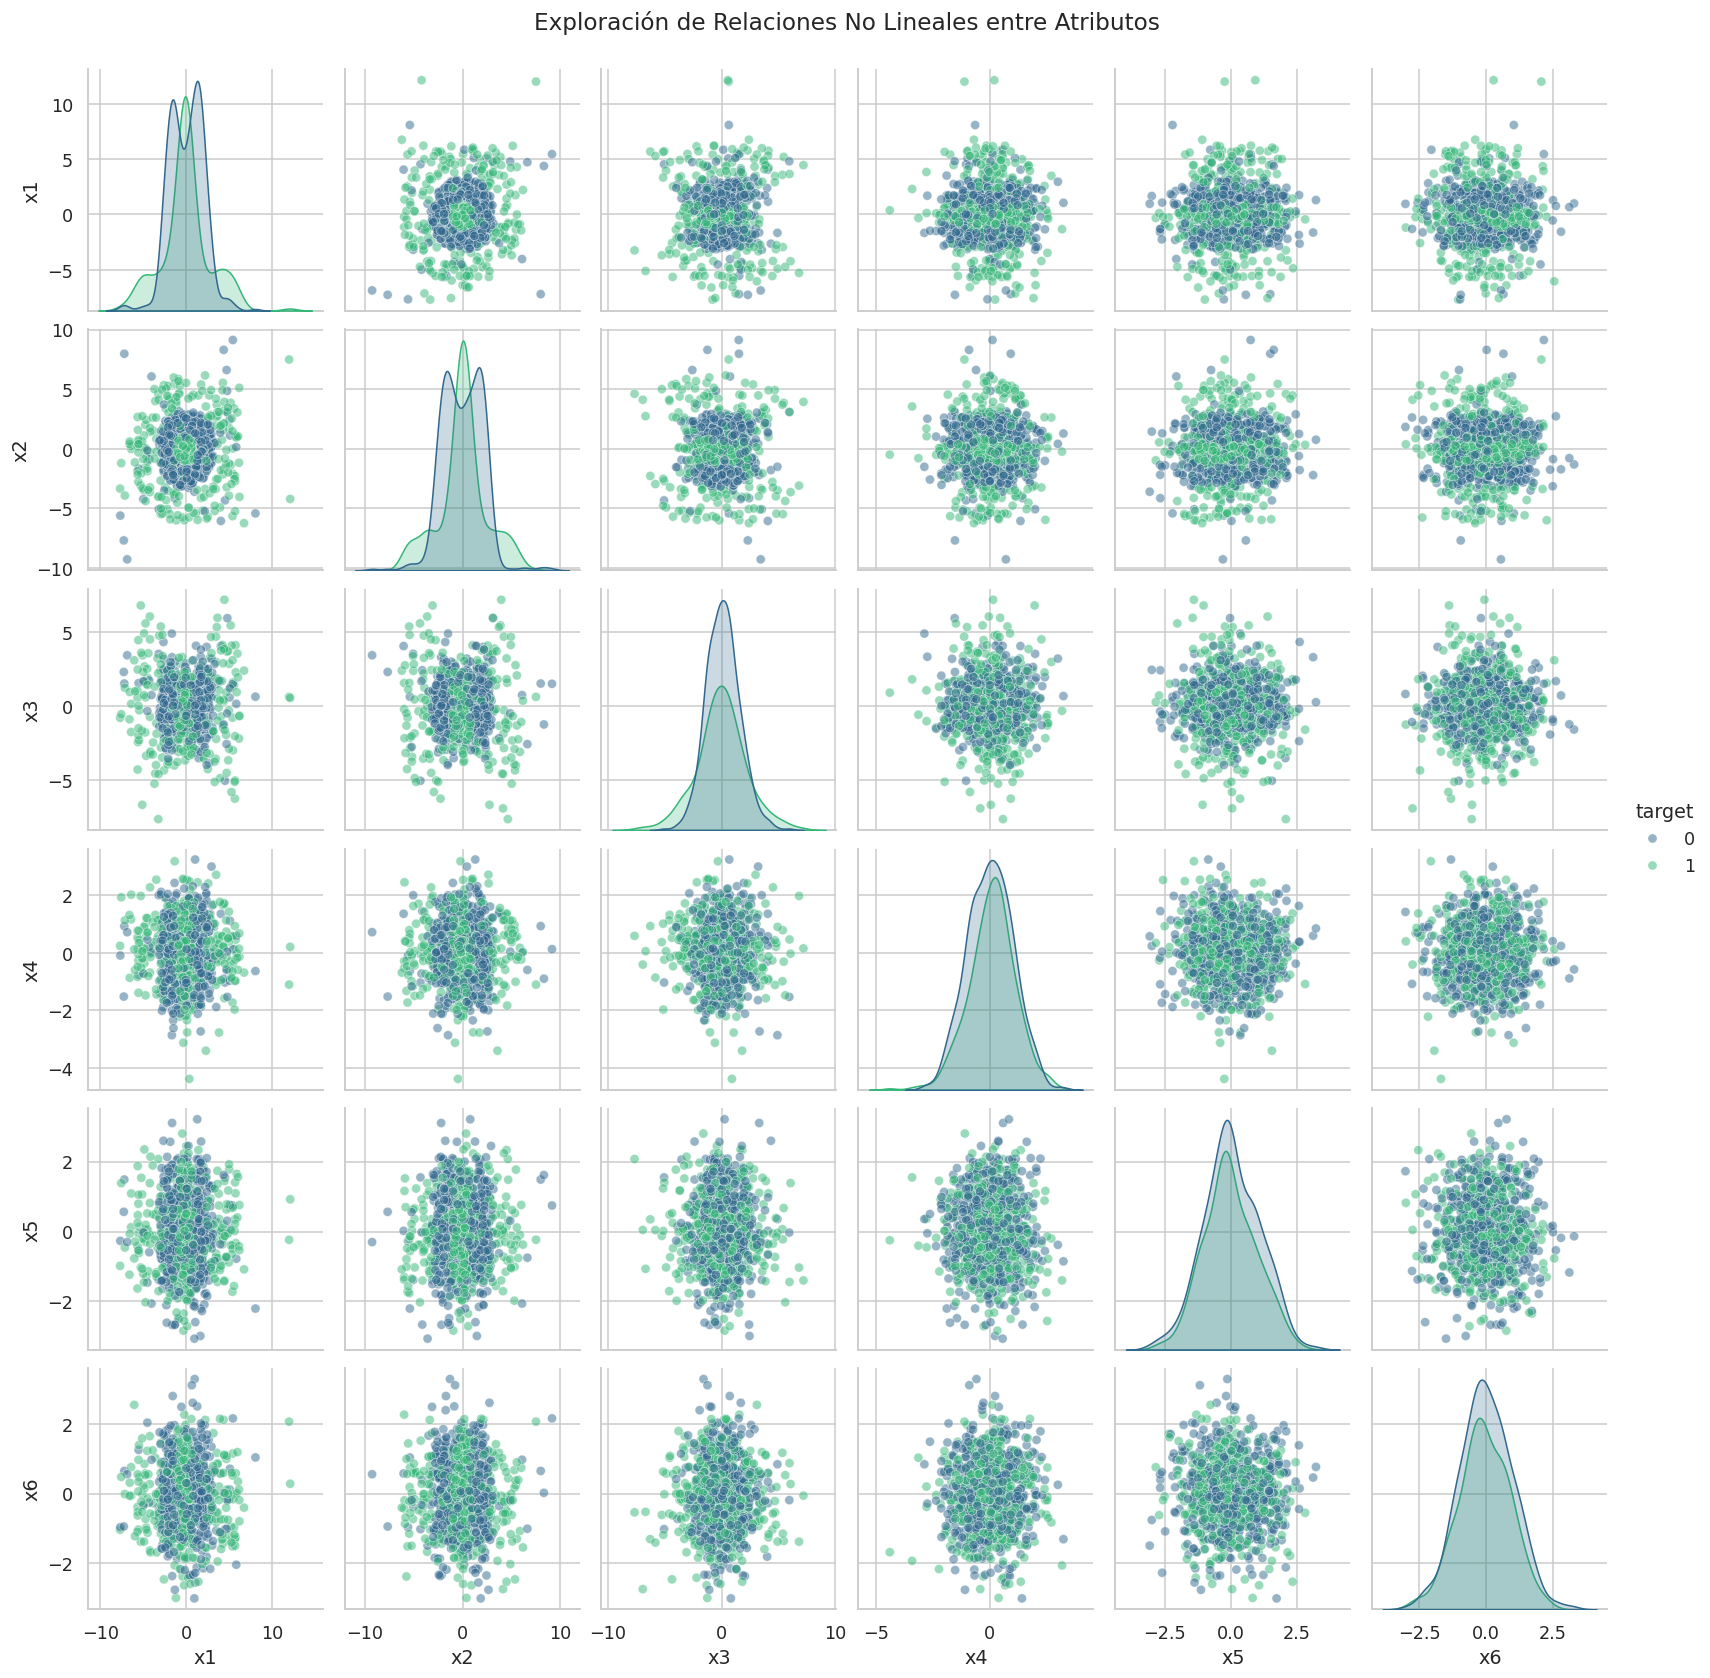

In [ ]:
# Visualizing non-linear relationships using a pairplot with hue
sns.pairplot(df, vars=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'], hue='target', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Exploración de Relaciones No Lineales entre Atributos', y=1.02)
plt.show()

El análisis visual sugiere que $x_1$ y $x_2$ poseen mayor capacidad discriminante para el valor (target = 1), mientras que $x_3$ se vincula mayoritariamente a la ausencia del evento (target = 0).La homogeneidad en los perfiles de x4, x5 y x6 indica una posible dependencia de un mismo proceso aleatorio o componente de ruido común.

# CONCLUSIONES

El análisis gráfico y las métricas de información mutua identifican a $x_1$ y $x_2$ como variables con alto poder discriminante respecto al target. Por el contrario, la relevancia de $x_3$ y $x_6$ resulta ambigua, sugiriendo un posible aporte de información complementaria o redundancia. Su capacidad predictiva final se determinará mediante un análisis de sensibilidad (feature selection), evaluando el desempeño del modelo sobre el conjunto de entrenamiento tras la inclusión y exclusión de dichas variables